## **Calofonia Housing Prediction**

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import scipy.stats as stats

## **Load dataset**

In [8]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


MedInc → Median income

HouseAge → Median house age

AveRooms → Average number of rooms per household

AveBedrms → Average number of bedrooms per household

Population → Block group population

AveOccup → Average household occupancy

Latitude and Longitude → Location coordinates

**Use one predictor: AveRooms**

In [11]:
# Use one predictor: AveRooms
X = df[['AveRooms']]
y = df['MedHouseVal']

**General info about the dataset**

In [14]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


**Summary statistics**

In [16]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Distribution plots**

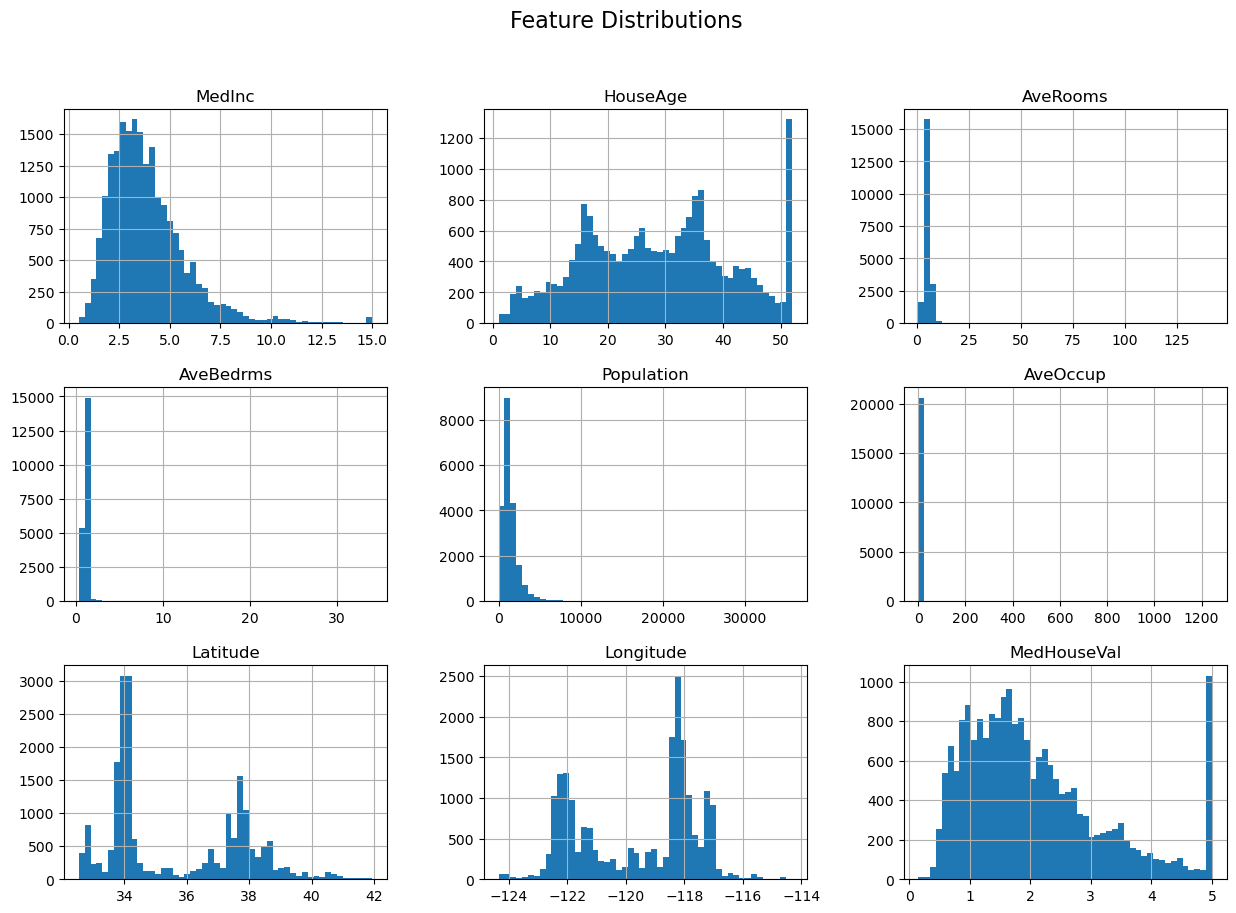

In [18]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


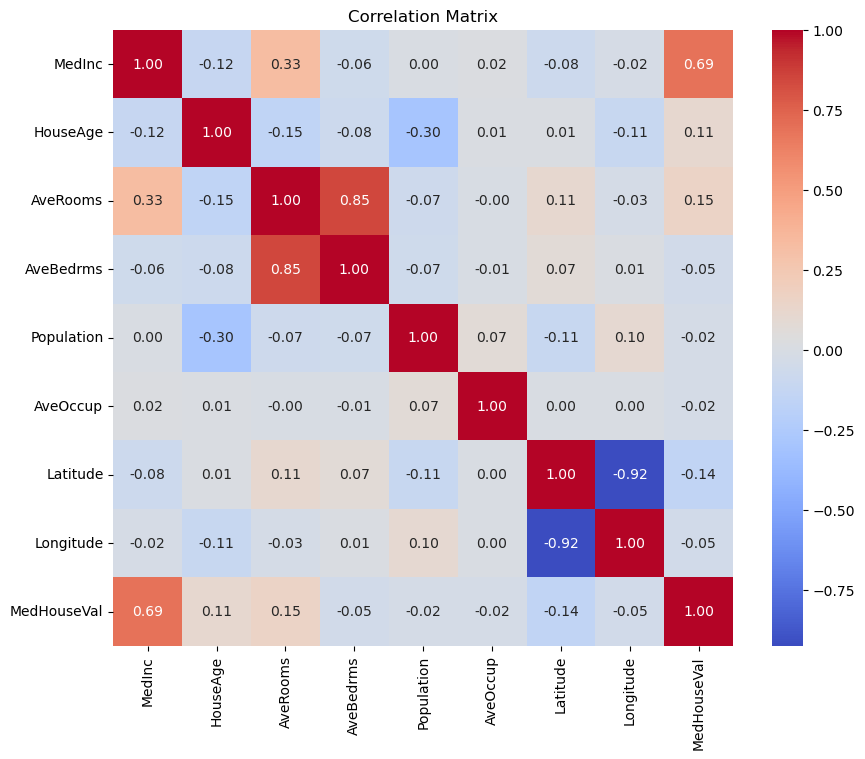

In [19]:
import seaborn as sns

corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


## **Model Selection**

### **Linear Regression Model**

**Let's use one predictor**

In [20]:
X = df[['AveRooms']]
y = df['MedHouseVal']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Fit the linear regression model**

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [24]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Predict**

In [41]:
# Step 1: Predict
y_pred = model.predict(X_test)

# Step 2: Display first few predicted values
print("Sample predicted values:", y_pred[:10])

# Optional: Compare with actual values side by side
import pandas as pd
comparison = pd.DataFrame({
    "Actual": y_test[:10].values,
    "Predicted": y_pred[:10]
})
print(comparison)


Sample predicted values: [1.97653709 2.04156313 1.96003112 2.12785581 2.07638001 2.05784293
 2.13231401 2.03568685 1.95600167 2.18276827]
    Actual  Predicted
0  0.47700   1.976537
1  0.45800   2.041563
2  5.00001   1.960031
3  2.18600   2.127856
4  2.78000   2.076380
5  1.58700   2.057843
6  1.98200   2.132314
7  1.57500   2.035687
8  3.40000   1.956002
9  4.46600   2.182768


## **Model Evaluation**

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate predictions
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Mean Squared Error (MSE): 1.2923314440807299
R² Score: 0.013795337532284901


R^2 is very, very low, so let's try multiple predictors

**Let's Use Multiple Predictors**

In [48]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Features (all predictors) and target
X = df.drop("MedHouseVal", axis=1)   # all features
y = df["MedHouseVal"]                # target variable

# 3. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Fit the multiple regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict on test set
y_pred = model.predict(X_test)

# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# 7. Optional: Display coefficients for each feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)


Mean Squared Error (MSE): 0.5558915986952437
R² Score: 0.5757877060324512
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


**Dropping AveBdrms**

In [50]:
# Drop 'AveBedrms' from features
X = df.drop(["MedHouseVal", "AveBedrms"], axis=1)
y = df["MedHouseVal"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

# Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)


MSE: 0.5473264990498133
R²: 0.5823239094526447
      Feature  Coefficient
0      MedInc     0.371939
1    HouseAge     0.009792
2    AveRooms     0.019116
3  Population    -0.000003
4    AveOccup    -0.003237
5    Latitude    -0.457872
6   Longitude    -0.464572


AveBedrms was dropped due to multicollinearity with AveRooms. Since both variables represent closely related housing characteristics, including both can introduce redundancy and reduce model interpretability. Removing AveBedrms helps simplify the model without significantly affecting predictive performance.

**Plot Actual vs Predicted Values**

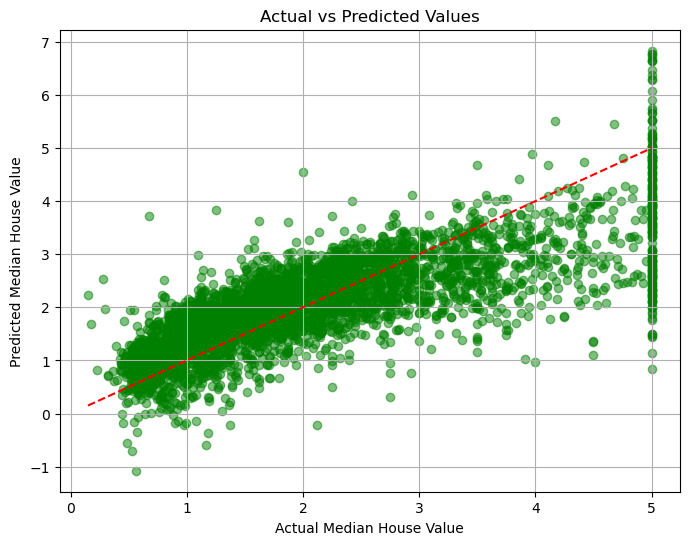

In [52]:
import matplotlib.pyplot as plt

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="green", alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()


Green dots: Each point represents a test sample.

Red dashed line: Ideal line where predicted = actual.

If points cluster tightly around the red line → good predictions.

If points scatter widely → model may be underfitting or missing key patterns.

In [55]:
# R² score on training data
r2_train = model.score(X_train, y_train)
print("Training R²:", r2_train)

# R² score on test data (already computed)
r2_test = model.score(X_test, y_test)
print("Test R²:", r2_test)


Training R²: 0.5995238502055928
Test R²: 0.5823239094526447


In [61]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Ridge regression
ridge_model = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = ridge_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 0.5558034669932207
R²: 0.5758549611440129


The model explains only 58% of the variance in house prices, meaning it lacks predictive power. This would make it unreliable for real estate pricing decisions.The model performance is limited, suggesting the need for more complex models or feature engineering before deployment.

## **Trying to use XGBRegressor**

In [63]:
import xgboost as xgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Define and train XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,       # number of trees
    learning_rate=0.05,     # step size shrinkage
    max_depth=6,            # depth of trees
    subsample=0.8,          # fraction of samples
    colsample_bytree=0.8,   # fraction of features
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 4. Predict
y_pred = xgb_model.predict(X_test)

# 5. Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost MSE:", mse)
print("XGBoost R²:", r2)


XGBoost MSE: 0.1998467096826389
XGBoost R²: 0.8474928720719586


In [65]:
# R² score on training data
r2_train = xgb_model.score(X_train, y_train)
print("Training R²:", r2_train)

# R² score on test data (already computed)
r2_test = xgb_model.score(X_test, y_test)
print("Test R²:", r2_test)


Training R²: 0.9414429566673793
Test R²: 0.8474928720719586


The model performed well but there is a sign of overfitting, so let's try cross-validation

**Cross Validation**

In [67]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Mean R²:", scores.mean())


Cross-validated R² scores: [0.60305685 0.71838693 0.76028421 0.70336528 0.62434402]
Mean R²: 0.6818874584069465


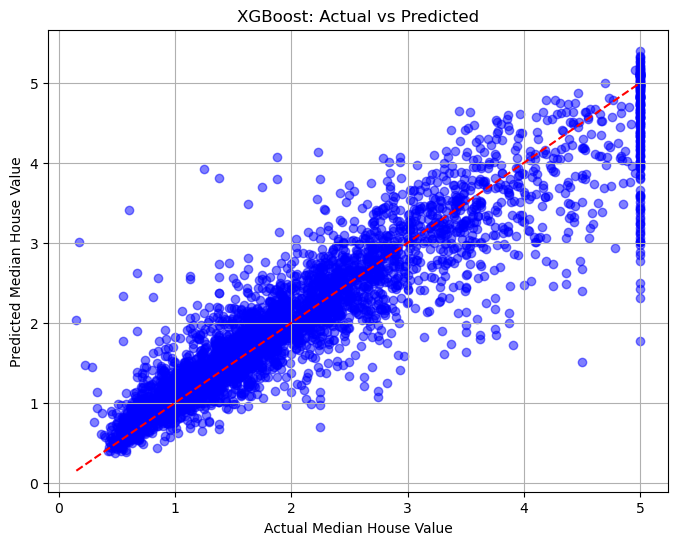

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("XGBoost: Actual vs Predicted")
plt.grid(True)
plt.show()


R^2 is still low after performing cross-validation(68%). I am now going to apply early stopping 

**Show top predictors**

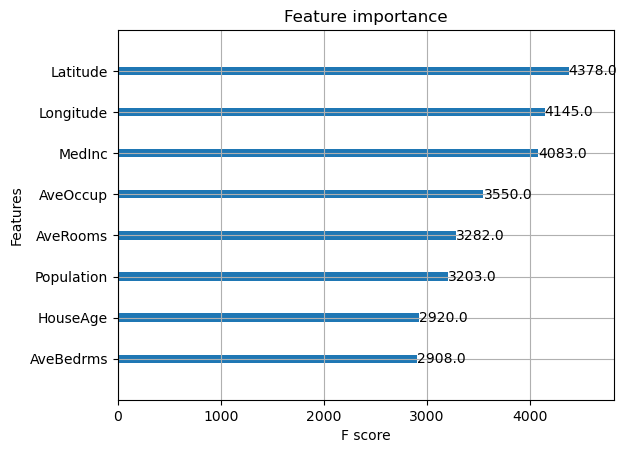

In [71]:
xgb.plot_importance(xgb_model)
plt.show()


**Apply Early Stopping**

In [78]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Load and split data
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)


In [80]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'rmse'
}

# Train with early stopping
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtest, 'eval')],
    early_stopping_rounds=20,
    verbose_eval=True
)


[0]	eval-rmse:1.12343
[1]	eval-rmse:1.09202
[2]	eval-rmse:1.06285
[3]	eval-rmse:1.03761
[4]	eval-rmse:1.01239
[5]	eval-rmse:0.99051
[6]	eval-rmse:0.96841
[7]	eval-rmse:0.94689
[8]	eval-rmse:0.92731
[9]	eval-rmse:0.91577
[10]	eval-rmse:0.89796
[11]	eval-rmse:0.88123
[12]	eval-rmse:0.86876
[13]	eval-rmse:0.85398
[14]	eval-rmse:0.84010
[15]	eval-rmse:0.82690
[16]	eval-rmse:0.81381
[17]	eval-rmse:0.80402
[18]	eval-rmse:0.79011
[19]	eval-rmse:0.77930
[20]	eval-rmse:0.76791
[21]	eval-rmse:0.75848
[22]	eval-rmse:0.75138
[23]	eval-rmse:0.74391
[24]	eval-rmse:0.73531
[25]	eval-rmse:0.72827
[26]	eval-rmse:0.72165
[27]	eval-rmse:0.71512
[28]	eval-rmse:0.70788
[29]	eval-rmse:0.70231
[30]	eval-rmse:0.69661
[31]	eval-rmse:0.69147
[32]	eval-rmse:0.68687
[33]	eval-rmse:0.68219
[34]	eval-rmse:0.67776
[35]	eval-rmse:0.67349
[36]	eval-rmse:0.66972
[37]	eval-rmse:0.66645
[38]	eval-rmse:0.66354
[39]	eval-rmse:0.65904
[40]	eval-rmse:0.65551
[41]	eval-rmse:0.65033
[42]	eval-rmse:0.64717
[43]	eval-rmse:0.6435

**Evaluate**

In [83]:
# Predict
y_train_pred = model.predict(dtrain)
y_test_pred = model.predict(dtest)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Test R²:", test_r2)
print("Training MSE:", train_mse)
print("Test MSE:", test_mse)


Training R²: 0.9066391385174569
Test R²: 0.8423748900990643
Training MSE: 0.12480276546375434
Test MSE: 0.20655335921039464


Early stopping was applied during the training of the XGBoost model to prevent overfitting. It works by monitoring the model’s performance on a validation set and stopping the training process once the performance no longer improves after a specified number of iterations.

The use of early stopping helped in achieving a better balance between bias and variance, resulting in improved performance on the test data. It ensured that the model did not become overly complex while still capturing important patterns in the data.

**Actual vs Predicted values**

First 10 predicted values (Test Set):
[0.48325446 0.9542934  4.9294124  2.4053142  2.434864   1.5808785
 2.3244982  1.5416993  2.9643047  4.751741  ]
Training R²: 0.9066391385174569
Test R²: 0.8423748900990643
Training MSE: 0.12480276546375434
Test MSE: 0.20655335921039464


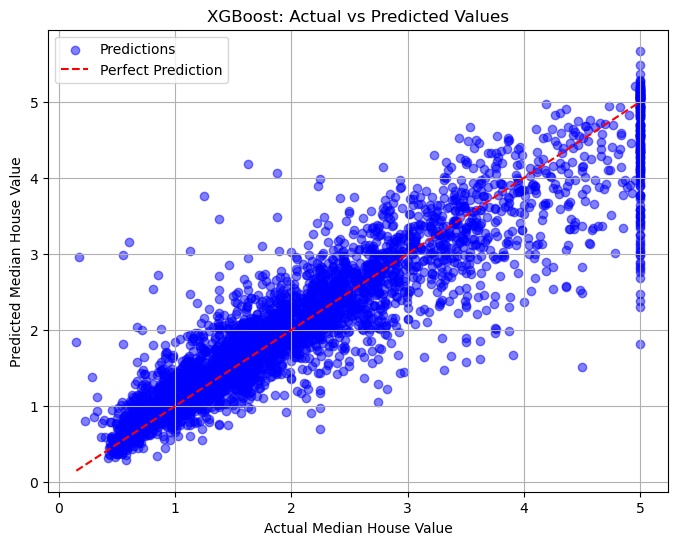

In [85]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# --- Predictions ---
y_train_pred = model.predict(dtrain)   # predictions on training set
y_test_pred = model.predict(dtest)     # predictions on test set

# --- Print first 10 predicted values ---
print("First 10 predicted values (Test Set):")
print(y_test_pred[:10])

# --- Evaluation metrics ---
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Test R²:", test_r2)
print("Training MSE:", train_mse)
print("Test MSE:", test_mse)

# --- Scatter plot: Actual vs Predicted ---
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, color="blue", alpha=0.5, label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("XGBoost: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()


## Model Comparison: XGBoost vs Linear Regression 

#### Performance Comparison

When comparing the models, XGBoost (with early stopping) significantly outperformed Linear Regression in terms of both R² score and Mean Squared Error (MSE). This indicates that XGBoost provides more accurate and reliable predictions for housing prices.

#### Reason for Performance Difference

Linear Regression assumes a simple linear relationship between features and the target variable. However, housing prices are influenced by complex, non-linear interactions between factors such as income, location, and population.

In contrast, XGBoost captures these non-linear relationships and feature interactions effectively. The addition of early stopping further improves performance by preventing overfitting and selecting the optimal number of boosting iterations.

#### Role of Early Stopping

Early stopping played a key role in enhancing XGBoost’s performance by halting training when the validation error stopped improving. This ensured that the model remained generalizable and did not overfit the training data, which is a common issue in powerful ensemble models.

#### Interpretation of Results
Linear Regression showed limited predictive power, suggesting underfitting due to its inability to model complex patterns.
XGBoost, enhanced with early stopping, achieved better generalization and higher accuracy.
The performance gap highlights the importance of using advanced models for non-linear datasets.

#### Business Insight

The superior performance of XGBoost suggests that it is more suitable for real estate price prediction tasks. While Linear Regression can provide a simple baseline, it may lead to inaccurate pricing decisions in real-world scenarios.

#### Final Conclusion
Among all models, XGBoost with early stopping achieved the best performance in terms of both R² score and MSE. Therefore, it is selected as the final model for house price prediction.

This model can assist real estate companies and policymakers in estimating housing prices more accurately. By leveraging XGBoost, stakeholders can better understand key drivers of property value and make data-driven pricing decisions. However, the model should be used alongside domain expertise for final decision-making.